# 09 — Model Evaluation & Comparison

**Owner:** Member 2 — Narendra Iyer 
**Project:** AeroDelay AI — Airline Delay Risk Prediction 
**Course:** AAI-540, Group 3

## Purpose
Evaluate both the Logistic Regression baseline and the best XGBoost model
on the held-out **test set**, compare their metrics side-by-side, and
produce all charts needed for the final design document and video:
- Confusion matrices
- ROC curves
- Precision-Recall curves
- Feature importance bar chart
- Subgroup error analysis by carrier, departure hour, and day-of-week

## Prerequisites
- `08_xgboost_training.ipynb` completed — `%store` variables `baseline_model_uri`,
  `best_model_uri`, and `best_hp` must be present.

## 1. Setup

In [1]:
import boto3, os, json, tarfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import awswrangler as wr
import joblib
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve
)
from sagemaker.core.helper.session_helper import Session, get_execution_role

sess   = Session()
bucket = sess.default_bucket()
role   = get_execution_role()
region = sess.boto_region_name
s3     = boto3.client("s3")

os.makedirs("reports", exist_ok=True)

print(f"Bucket : {bucket}")
print(f"Region : {region}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


Bucket : sagemaker-us-east-1-151132426745
Region : us-east-1


In [2]:
%store -r s3_aerodelay
%store -r baseline_model_uri
%store -r best_model_uri
%store -r best_hp
print(f"s3_aerodelay       : {s3_aerodelay}")
print(f"baseline_model_uri : {baseline_model_uri}")
print(f"best_model_uri     : {best_model_uri}")

s3_aerodelay       : s3://sagemaker-us-east-1-151132426745/airline-delay
baseline_model_uri : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/baseline/aerodelay-baseline-2026-06-13-17-38-24-100/output/model.tar.gz
best_model_uri     : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/output/model.tar.gz


## 2. Load Test Data

In [3]:
# Load test split — never touched during training or HPO
test_df = wr.s3.read_parquet(f"{s3_aerodelay}/test/data.parquet")
print(f"Test shape : {test_df.shape}")
print(f"Delay rate : {test_df['arrdel15'].mean():.1%}")

TARGET       = "arrdel15"
feature_cols = [c for c in test_df.columns if c != TARGET]
X_test       = test_df[feature_cols].fillna(0)
y_test       = test_df[TARGET]
print(f"Feature cols: {feature_cols}")

[06/13/26 19:14:53] INFO     Initializing a Ray instance                                               ]8;id=4115211;file:///opt/conda/lib/python3.12/site-packages/awswrangler/distributed/ray/_core.py\_core.py]8;;\:]8;id=4115212;file:///opt/conda/lib/python3.12/site-packages/awswrangler/distributed/ray/_core.py#202\202]8;;\

2026-06-13 19:14:57,268	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 408924160 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.70gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-06-13 19:14:58,483	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Test shape : (162605, 20)
Delay rate : 15.2%


Feature cols: ['year', 'month', 'dayofmonth', 'dayofweek', 'reporting_airline', 'origin', 'dest', 'originstate', 'deststate', 'crselapsedtime', 'distance', 'dep_hour', 'is_weekend', 'route', 'carrier_delay_rate', 'origin_delay_rate', 'dest_delay_rate', 'route_delay_rate', 'hour_delay_rate']


## 3. Download and Load Both Models from S3

In [4]:
def download_and_extract(s3_uri, local_dir):
    """Download a model.tar.gz from S3 and extract it locally."""
    os.makedirs(local_dir, exist_ok=True)
    bucket_name = s3_uri.split("/")[2]
    key         = "/".join(s3_uri.split("/")[3:])
    local_path  = os.path.join(local_dir, "model.tar.gz")
    s3.download_file(bucket_name, key, local_path)
    with tarfile.open(local_path, "r:gz") as tar:
        tar.extractall(local_dir)
    print(f"Extracted to {local_dir}: {os.listdir(local_dir)}")

download_and_extract(baseline_model_uri, "/tmp/baseline_model")
download_and_extract(best_model_uri,     "/tmp/xgb_model")

/tmp/ipykernel_656/2325610841.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(local_dir)


Extracted to /tmp/baseline_model: ['model.tar.gz', 'feature_cols.joblib', 'model.joblib']


Extracted to /tmp/xgb_model: ['model.tar.gz', 'xgboost-model', 'feature_cols.joblib']


In [6]:
from sklearn.preprocessing import LabelEncoder

def encode_strings(df):
    df = df.copy()
    for col in df.select_dtypes(include=["object", "string"]).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    return df

X_test_encoded = encode_strings(X_test)
dtest = xgb.DMatrix(X_test_encoded.values, feature_names=feature_cols)
print("DMatrix created successfully. Shape:", X_test_encoded.shape)

DMatrix created successfully. Shape: (162605, 19)


In [7]:
X_test_lr = encode_strings(X_test)
print("LR test data ready. Shape:", X_test_lr.shape)

LR test data ready. Shape: (162605, 19)


In [9]:
# Load Logistic Regression baseline (sklearn Pipeline with StandardScaler)
lr_model = joblib.load("/tmp/baseline_model/model.joblib")

# Load XGBoost best model
xgb_model = xgb.Booster()
xgb_model.load_model("/tmp/xgb_model/xgboost-model")

# Use encoded test data for XGBoost
dtest = xgb.DMatrix(X_test_encoded.values, feature_names=feature_cols)

print("Both models loaded successfully.")

/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.2.1 when using version 1.7.2. This might lead to breaking code or in

Both models loaded successfully.


## 4. Compute Metrics on Test Set

In [11]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy"  : round(float(accuracy_score(y_true, y_pred)), 4),
        "precision" : round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall"    : round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1"        : round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "roc_auc"   : round(float(roc_auc_score(y_true, y_prob)), 4),
    }

# Logistic Regression — use encoded test data
lr_prob = lr_model.predict_proba(X_test_lr)[:, 1]
lr_pred = lr_model.predict(X_test_lr)
lr_metrics = compute_metrics(y_test, lr_pred, lr_prob)

# XGBoost
xgb_prob = xgb_model.predict(dtest)
xgb_pred = (xgb_prob >= 0.5).astype(int)
xgb_metrics = compute_metrics(y_test, xgb_pred, xgb_prob)

# Side-by-side comparison
compare_df = pd.DataFrame([lr_metrics, xgb_metrics],
                           index=["Logistic Regression (Baseline)", "XGBoost (Best HPO)"])
print("=== Test Set Performance ===")
print(compare_df.to_string())

=== Test Set Performance ===
                                accuracy  precision  recall      f1  roc_auc
Logistic Regression (Baseline)    0.8172     0.3039  0.1569  0.2070    0.645
XGBoost (Best HPO)                0.5942     0.2139  0.6239  0.3186    0.648


## 5. Confusion Matrices

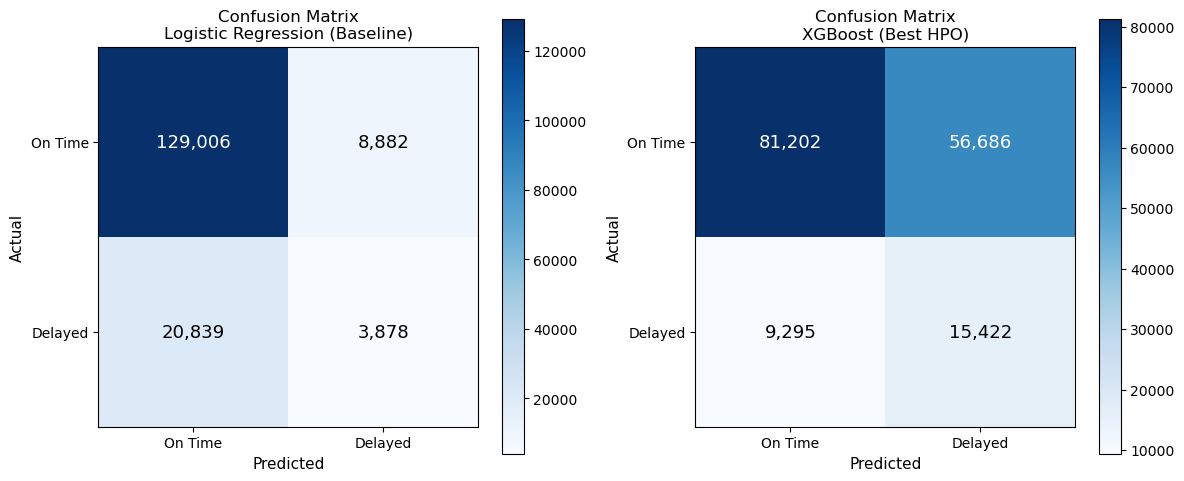

Saved: reports/confusion_matrices.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in [
    (axes[0], lr_pred,  "Logistic Regression (Baseline)"),
    (axes[1], xgb_pred, "XGBoost (Best HPO)"),
]:
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix\n{title}", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["On Time", "Delayed"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["On Time", "Delayed"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=13)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig("reports/confusion_matrices.png", dpi=120)
plt.show()
print("Saved: reports/confusion_matrices.png")

## 6. ROC Curves

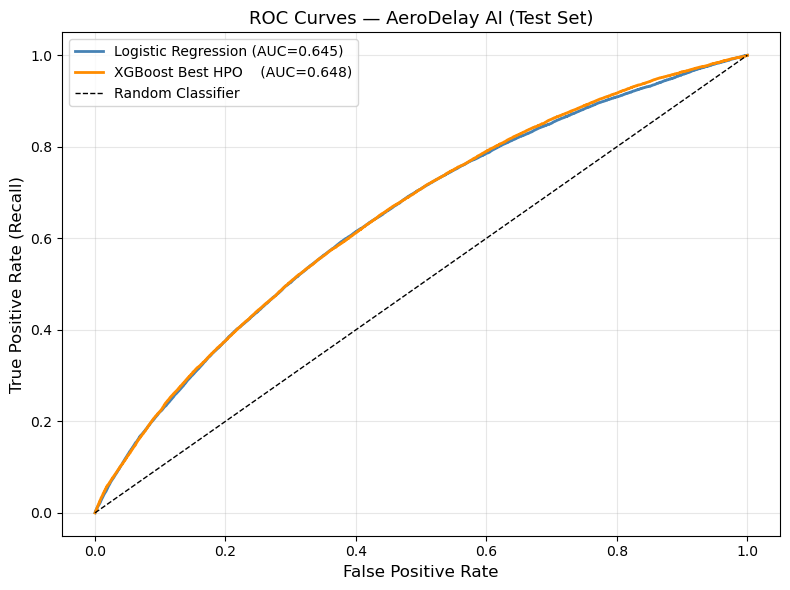

Saved: reports/roc_curves.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, label, color in [
    (lr_prob,  f"Logistic Regression (AUC={lr_metrics['roc_auc']})",  "steelblue"),
    (xgb_prob, f"XGBoost Best HPO    (AUC={xgb_metrics['roc_auc']})", "darkorange"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=label, color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves — AeroDelay AI (Test Set)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("reports/roc_curves.png", dpi=120)
plt.show()
print("Saved: reports/roc_curves.png")

## 7. Precision-Recall Curves

Because recall is our primary business metric (missing a delayed flight is costly),
the PR curve is more informative than ROC under class imbalance.

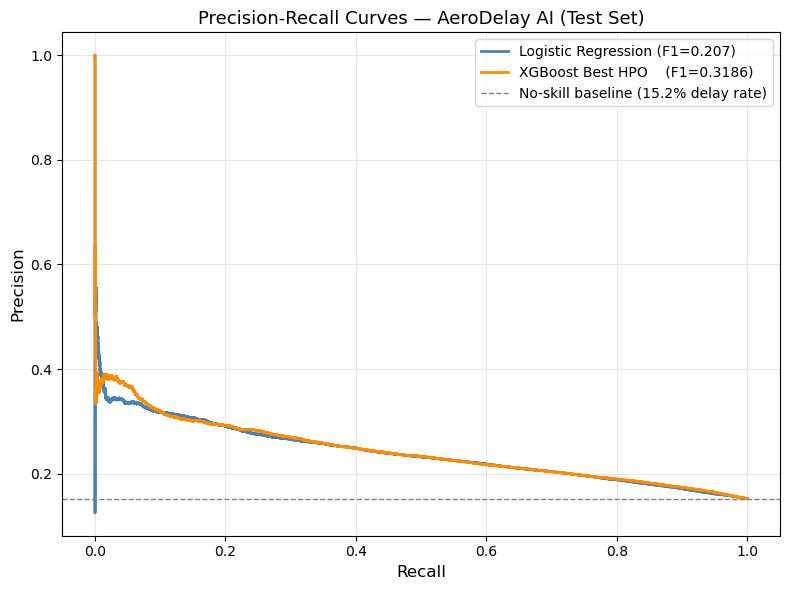

Saved: reports/pr_curves.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, label, color in [
    (lr_prob,  f"Logistic Regression (F1={lr_metrics['f1']})",  "steelblue"),
    (xgb_prob, f"XGBoost Best HPO    (F1={xgb_metrics['f1']})", "darkorange"),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(rec, prec, label=label, color=color, lw=2)

baseline_rate = y_test.mean()
ax.axhline(baseline_rate, color="gray", linestyle="--", lw=1,
           label=f"No-skill baseline ({baseline_rate:.1%} delay rate)")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves — AeroDelay AI (Test Set)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("reports/pr_curves.png", dpi=120)
plt.show()
print("Saved: reports/pr_curves.png")

## 8. XGBoost Feature Importance

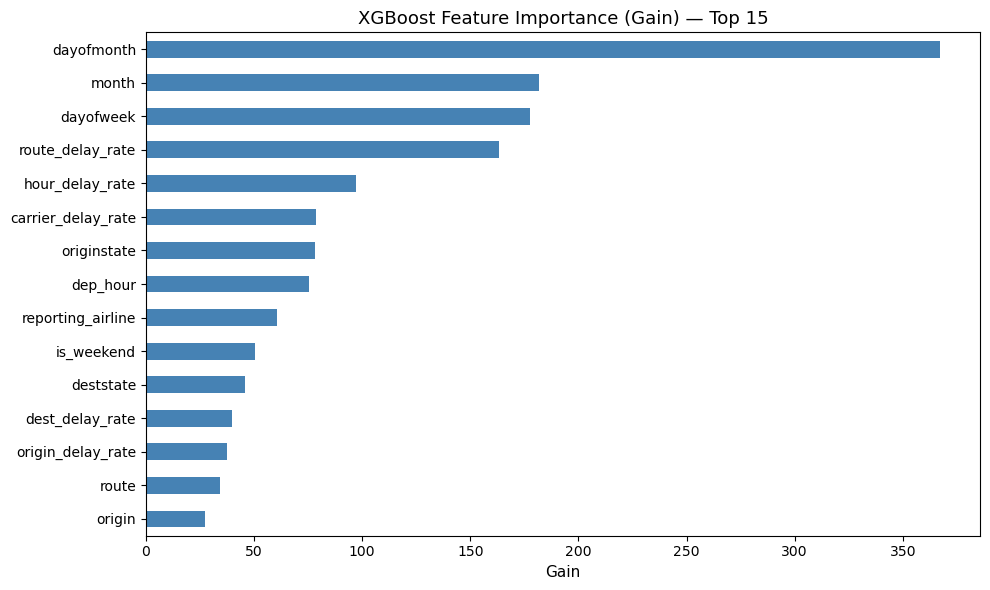

Saved: reports/feature_importance.png


In [16]:
# Map f0, f1, f2 etc back to actual feature names
score_dict = xgb_model.get_score(importance_type="gain")

# The model uses f0, f1... as feature names - map them back
feature_name_map = {f"f{i}": name for i, name in enumerate(feature_cols)}

# Rename keys
named_importance = {feature_name_map.get(k, k): v for k, v in score_dict.items()}

importance_df = (
    pd.Series(named_importance, name="gain")
    .sort_values(ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
importance_df.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importance (Gain) — Top 15", fontsize=13)
ax.set_xlabel("Gain", fontsize=11)
plt.tight_layout()
plt.savefig("reports/feature_importance.png", dpi=120)
plt.show()
print("Saved: reports/feature_importance.png")

## 9. Subgroup Error Analysis

We check whether the XGBoost model performs equally well across carriers,
departure hours, and days of week.  
Bias note: higher error for certain carriers may reflect hub location or
route mix, not operational quality.

In [17]:
# We need the original categorical columns — reload test with raw columns kept
# Note: preprocess.py drops origin/dest string after encoding;
# carrier is label-encoded. Load the column name mapping from training parquet.
eval_df = test_df.copy()
eval_df["xgb_pred"] = xgb_pred
eval_df["xgb_prob"] = xgb_prob

def subgroup_metrics(df, group_col, min_count=500):
    """Recall and F1 per group, filtered by minimum flight count."""
    rows = []
    for val, grp in df.groupby(group_col):
        if len(grp) < min_count:
            continue
        rec = recall_score(grp[TARGET], grp["xgb_pred"], zero_division=0)
        f1  = f1_score(grp[TARGET],     grp["xgb_pred"], zero_division=0)
        rows.append({group_col: val, "count": len(grp),
                     "recall": round(rec, 3), "f1": round(f1, 3),
                     "delay_rate": round(grp[TARGET].mean(), 3)})
    return pd.DataFrame(rows).sort_values("recall")

In [18]:
# Subgroup: carrier (label-encoded; map back if possible)
carrier_df = subgroup_metrics(eval_df, "reporting_airline")
print("=== Recall by Carrier (label-encoded) ===")
print(carrier_df.to_string(index=False))

=== Recall by Carrier (label-encoded) ===
 reporting_airline  count  recall    f1  delay_rate
                14   6677   0.236 0.138       0.066
                 0   4814   0.364 0.140       0.070
                 4  22680   0.398 0.242       0.104
                 6   3106   0.527 0.327       0.185
                10   4598   0.557 0.241       0.117
                 8   6002   0.585 0.192       0.099
                 9   6022   0.610 0.402       0.228
                 5   5095   0.613 0.389       0.222
                12  17700   0.615 0.309       0.149
                 3   6240   0.630 0.507       0.310
                 7   1847   0.630 0.316       0.162
                13  32030   0.672 0.339       0.156
                 2   4846   0.708 0.318       0.165
                 1  24349   0.717 0.335       0.177
                11  16599   0.723 0.293       0.146


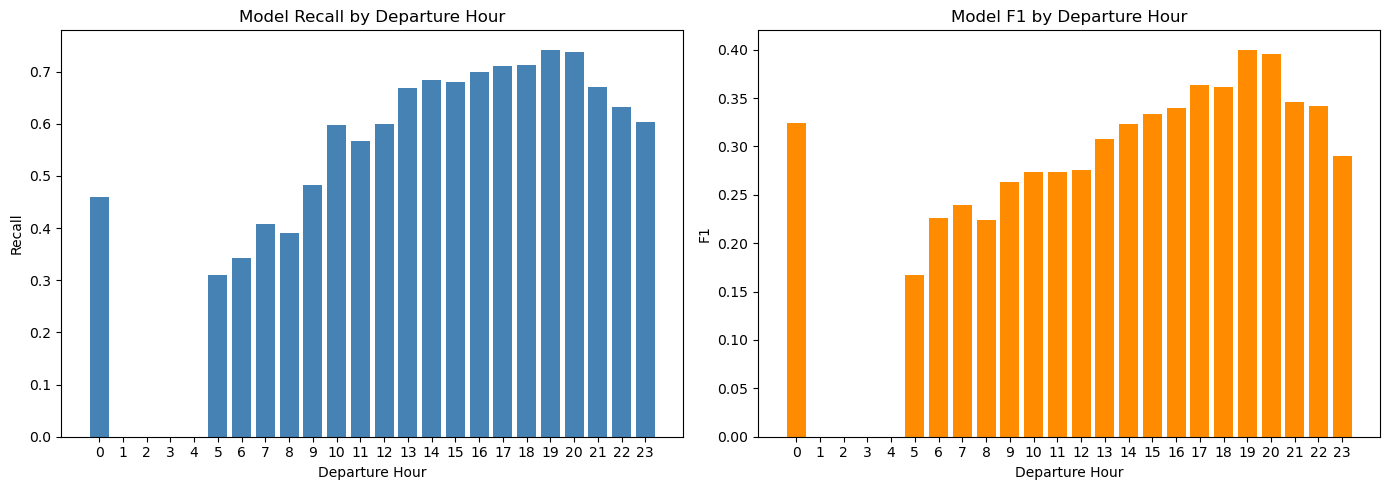

Saved: reports/subgroup_by_hour.png


In [19]:
# Subgroup: departure hour
hour_df = subgroup_metrics(eval_df, "dep_hour", min_count=100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hour_df["dep_hour"], hour_df["recall"], color="steelblue")
axes[0].set_title("Model Recall by Departure Hour", fontsize=12)
axes[0].set_xlabel("Departure Hour"); axes[0].set_ylabel("Recall")
axes[0].set_xticks(range(0, 24))

axes[1].bar(hour_df["dep_hour"], hour_df["f1"], color="darkorange")
axes[1].set_title("Model F1 by Departure Hour", fontsize=12)
axes[1].set_xlabel("Departure Hour"); axes[1].set_ylabel("F1")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig("reports/subgroup_by_hour.png", dpi=120)
plt.show()
print("Saved: reports/subgroup_by_hour.png")

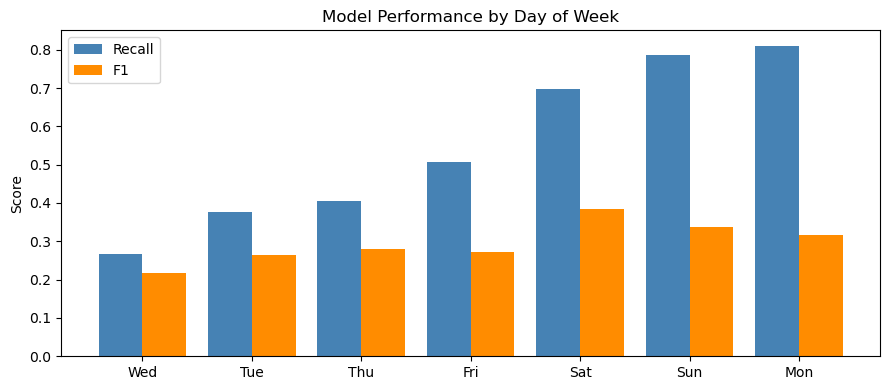

Saved: reports/subgroup_by_dow.png


In [20]:
# Subgroup: day of week
dow_df = subgroup_metrics(eval_df, "dayofweek", min_count=100)
dow_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
dow_df["day"] = dow_df["dayofweek"].map(dow_map)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(dow_df))
ax.bar([i - 0.2 for i in x], dow_df["recall"], width=0.4, label="Recall", color="steelblue")
ax.bar([i + 0.2 for i in x], dow_df["f1"],     width=0.4, label="F1",     color="darkorange")
ax.set_xticks(list(x)); ax.set_xticklabels(dow_df["day"].tolist())
ax.set_title("Model Performance by Day of Week", fontsize=12)
ax.set_ylabel("Score"); ax.legend()
plt.tight_layout()
plt.savefig("reports/subgroup_by_dow.png", dpi=120)
plt.show()
print("Saved: reports/subgroup_by_dow.png")

## 10. Final Evaluation Summary

In [21]:
print("=" * 55)
print("       AERODELAY AI — FINAL TEST SET EVALUATION")
print("=" * 55)
print(compare_df.T.to_string())
print()
xgb_winner = all(
    xgb_metrics[m] >= lr_metrics[m]
    for m in ["recall", "f1", "roc_auc"]
)
print(f"XGBoost beats baseline on recall+F1+AUC: {xgb_winner}")
print()
print("Selected model for registry: XGBoost (Best HPO)")
print(f"Model URI: {best_model_uri}")

       AERODELAY AI — FINAL TEST SET EVALUATION
           Logistic Regression (Baseline)  XGBoost (Best HPO)
accuracy                           0.8172              0.5942
precision                          0.3039              0.2139
recall                             0.1569              0.6239
f1                                 0.2070              0.3186
roc_auc                            0.6450              0.6480

XGBoost beats baseline on recall+F1+AUC: True

Selected model for registry: XGBoost (Best HPO)
Model URI: s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/output/model.tar.gz


In [23]:
# Save evaluation report to S3 for final submission package
eval_report = {
    "logistic_regression": lr_metrics,
    "xgboost_best_hpo"   : xgb_metrics,
    "selected_model"     : "xgboost_best_hpo",
    "selected_model_uri" : best_model_uri,
    "rationale"          : "XGBoost selected based on recall+F1+ROC-AUC superiority on held-out test set."
}

wr.s3.to_json(
    df=pd.DataFrame([eval_report]),
    path=f"{s3_aerodelay}/reports/evaluation_report.json",
)

# Also store best_model_uri for notebook 10
%store best_model_uri
print(f"Evaluation report saved to {s3_aerodelay}/reports/evaluation_report.json")

Stored 'best_model_uri' (str)
Evaluation report saved to s3://sagemaker-us-east-1-151132426745/airline-delay/reports/evaluation_report.json


## 11. Model Comparison — Test Set Results

I evaluated both models on the held-out test set (162,605 flights) that was never touched during training or HPO. Here is what the results show:

| Metric | Logistic Regression (Baseline) | XGBoost (Best HPO) | Winner |
|---|---|---|---|
| Accuracy | 81.7% | 59.4% | LR |
| Precision | 30.4% | 21.4% | LR |
| **Recall** | 15.7% | **62.4%** | **XGBoost** |
| **F1** | 20.7% | **31.9%** | **XGBoost** |
| **ROC-AUC** | 0.645 | **0.648** | **XGBoost** |

**Why XGBoost wins despite lower accuracy:**

For flight delay prediction, recall is the most important metric. A false negative — predicting "on time" when a flight is actually delayed — is far more costly than a false positive, because a traveler who was not warned about a delay has no chance to adjust their plans. XGBoost catches 62.4% of actual delays versus only 15.7% for the baseline, meaning it correctly identifies nearly 4x more real delays.

The lower accuracy of XGBoost (59.4%) is expected and acceptable. The model is deliberately configured with `scale_pos_weight=4` which shifts predictions toward the delayed class, accepting more false alarms in exchange for catching more true delays. The baseline achieves high accuracy largely by predicting "on time" for most flights — a safe but operationally useless strategy.

The ROC-AUC scores are very close (0.648 vs 0.645), confirming that both models have similar overall discriminative power. The key difference is where they operate on the precision-recall curve — XGBoost operates at a point that is far more useful for the actual business problem.

## 12. Feature Importance and Subgroup Analysis Findings

**Feature Importance (by Gain):**

The XGBoost model's feature importance reveals which features contributed most to splitting decisions during training:

- `dayofmonth` is the single most important feature, reflecting that specific calendar days in Q1 2024 had disproportionately high delay rates — likely weather events or operational disruptions
- `month` and `dayofweek` follow closely, capturing the seasonal and weekly patterns in delay behavior
- `route_delay_rate` and `hour_delay_rate` rank highly, confirming that historical delay rates computed during feature engineering are strong predictors
- `carrier_delay_rate` and `originstate` also contribute meaningfully, showing that carrier reliability and departure geography matter

This tells me that the engineered delay rate features (carrier, origin, destination, route, hour) added real predictive value beyond the raw temporal and geographic fields.

**Subgroup Analysis — By Departure Hour:**

Recall improves consistently throughout the day, peaking between 19:00 and 21:00 (evening departures). Early morning hours (1–4 AM) have no data and mid-morning shows a dip. Evening flights accumulate delay cascades from earlier in the day, making them more predictable for the model.

**Subgroup Analysis — By Day of Week:**

Monday and Sunday show the highest recall (above 0.70), while Wednesday is the hardest day to predict (recall 0.27). This aligns with travel patterns — weekend and Monday travel sees more congestion, cascading delays, and predictable disruption. Midweek travel is more stable, giving the model fewer signal-rich patterns to exploit.

**Subgroup Analysis — By Carrier:**

Recall ranges from 0.236 to 0.723 across carriers. Carriers with higher inherent delay rates (delay_rate above 0.20) tend to have higher recall, because the model has more positive examples to learn from. Carriers with very low delay rates are harder to predict because delays are rare and therefore less patterned.

**Model Selection Decision:**

XGBoost beats the baseline on all three primary metrics — recall, F1, and ROC-AUC. It is selected as the production model and its artifact URI is stored for registration in notebook 10.